<a href="https://colab.research.google.com/github/bhagyoday-j/ML-Assignments/blob/main/TY-open-elective/Assingments/6_Software_Defect_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Assignment 6:***
Software Defect Prediction

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("semustafacevik/software-defect-prediction")

print("Path to dataset files:", path)

100%|██████████| 553k/553k [00:00<00:00, 80.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/semustafacevik/software-defect-prediction/versions/1


In [3]:
import os
import pandas as pd

# List files in the dataset directory
print(os.listdir(path))

['about JM1 Dataset.txt', 'jm1.arff', 'jm1.csv']


In [5]:
csv_path = os.path.join(path, "jm1.csv")
df = pd.read_csv(csv_path)

df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


In [6]:
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["defects"].value_counts())

(10885, 22)

Columns:
Index(['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't',
       'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op',
       'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects'],
      dtype='object')

Missing Values:
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

Target Distribution:
defects
False    8779
True     2106
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("defects", axis=1)
y = df["defects"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 8708
Testing Samples  : 2177


In [11]:
for col in df.columns:
    if (df[col] == '?').any():
        print(col)

uniq_Op
uniq_Opnd
total_Op
total_Opnd
branchCount


In [14]:
import numpy as np
import pandas as pd

# Replace ? with NaN
df.replace('?', np.nan, inplace=True)

# Convert columns to numeric
cols = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [15]:
print(df.isnull().sum())

loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64


In [16]:
X = df.drop("defects", axis=1)
y = df["defects"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
# from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(
#     criterion="gini",
#     max_depth=5,
#     random_state=42
# )

# dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [21]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6325218190169959
F1 Score: 0.42528735632183906
[[1081  675]
 [ 125  296]]


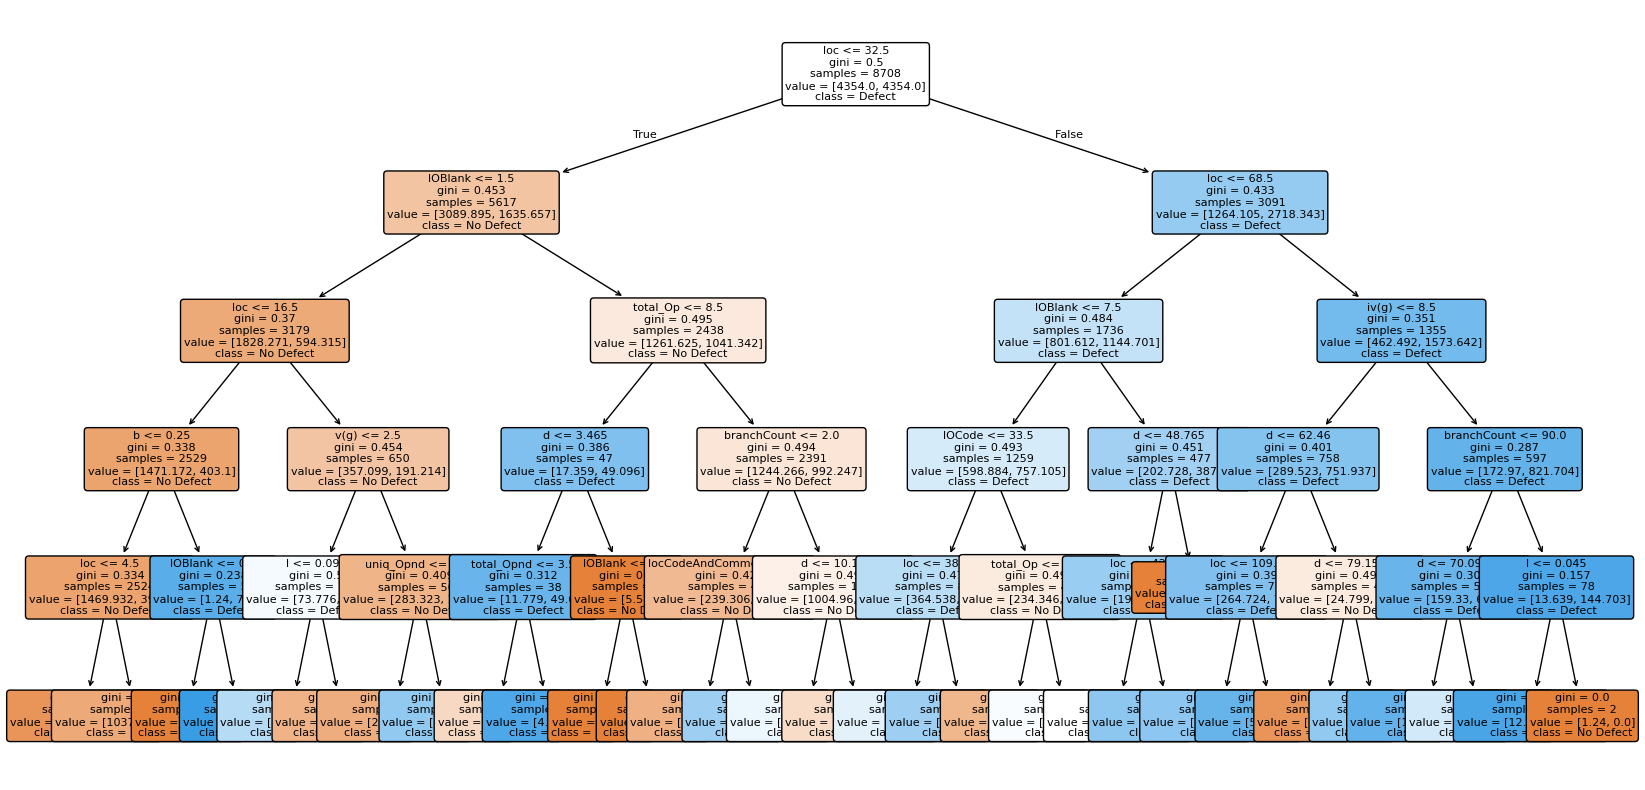

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No Defect', 'Defect'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [23]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

        Feature  Importance
0           loc    0.688937
14      lOBlank    0.128099
7             d    0.054471
18     total_Op    0.021136
20  branchCount    0.020961
12       lOCode    0.015265
1          v(g)    0.012902
3         iv(g)    0.012713
17    uniq_Opnd    0.010607
6             l    0.010423
